In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import (bernoulli, binom, poisson, geom, nbinom, hypergeom,
                         multinomial, norm, lognorm, uniform, expon, gamma, beta,
                         t, chi2, f)

from scipy import stats

rng = np.random.default_rng(42)
import pandas as pd
import math

In [4]:
N = 1000  # sample size

plt.rcParams.update({"figure.figsize": (12, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
THEORY = "#24658A"
SAMPLE = "#C16A24"

Bernoulli

Bernoulli: p = 0.2
First 10 observations: [0 0 1 0 0 1 0 0 0 0]
Theory: mean=0.200, variance=0.160, SD=0.400
Sample: mean=0.197, variance=0.158, SD=0.398
Bernoulli: p = 0.7
First 10 observations: [1 1 1 1 1 1 0 1 0 1]
Theory: mean=0.700, variance=0.210, SD=0.458
Sample: mean=0.686, variance=0.216, SD=0.464


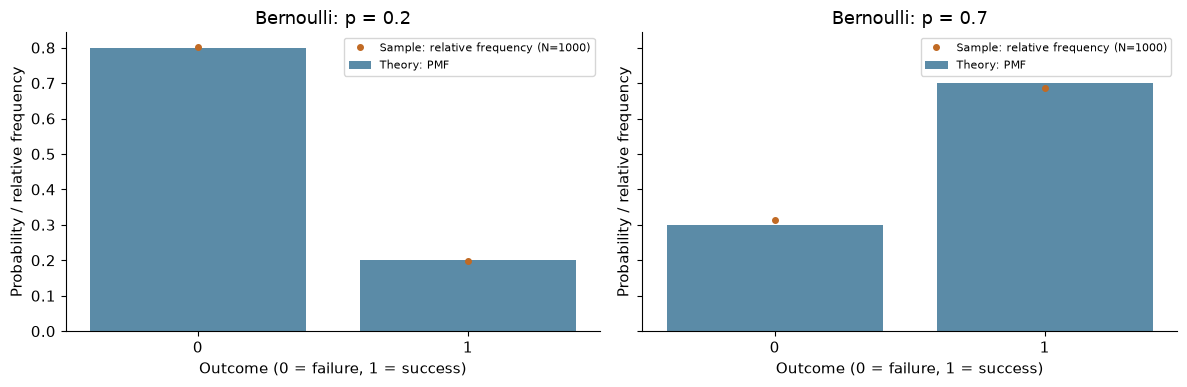

In [5]:
cases = [("Bernoulli: p = 0.2", bernoulli(p=0.2)), ("Bernoulli: p = 0.7", bernoulli(p=0.7))]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
left = min(int(model.ppf(0.001)) for _, model in cases)
right = max(int(model.ppf(0.999)) for _, model in cases)
k = np.arange(left, right + 1)

for ax, (label, model) in zip(axes, cases):
    probabilities = model.pmf(k)  # theoretical proaility for each k
    data = model.rvs(size=N, random_state=rng)  # random sample
    relative_frequency = np.array([np.mean(data == value) for value in k])

    ax.bar(k, probabilities, color=THEORY, alpha=0.75, label="Theory: PMF")
    ax.plot(k, relative_frequency, "o", color=SAMPLE, markersize=4,
            label=f"Sample: relative frequency (N={N})")
    ax.set_title(label)
    ax.set_xlabel('Outcome (0 = failure, 1 = success)')
    ax.set_ylabel("Probability / relative frequency")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    if len(k) <= 16:
        ax.set_xticks(k)
    ax.legend(fontsize=8)
    print(label)
    print("First 10 observations:", data[:10])
    print(f"Theory: mean={model.mean():.3f}, variance={model.var():.3f}, SD={model.std():.3f}")
    print(f"Sample: mean={data.mean():.3f}, variance={data.var(ddof=1):.3f}, SD={data.std(ddof=1):.3f}")

plt.tight_layout()
plt.show()

Binominal

Binomial: n = 10, p = 0.2
First 10 observations: [3 2 4 2 1 4 2 1 1 3]
Theory: mean=2.000, variance=1.600, SD=1.265
Sample: mean=1.981, median=2.000, variance=1.666, SD=1.291
Binomial: n = 10, p = 0.7
First 10 observations: [6 7 8 6 9 6 7 9 9 6]
Theory: mean=7.000, variance=2.100, SD=1.449
Sample: mean=7.032, median=7.000, variance=2.125, SD=1.458


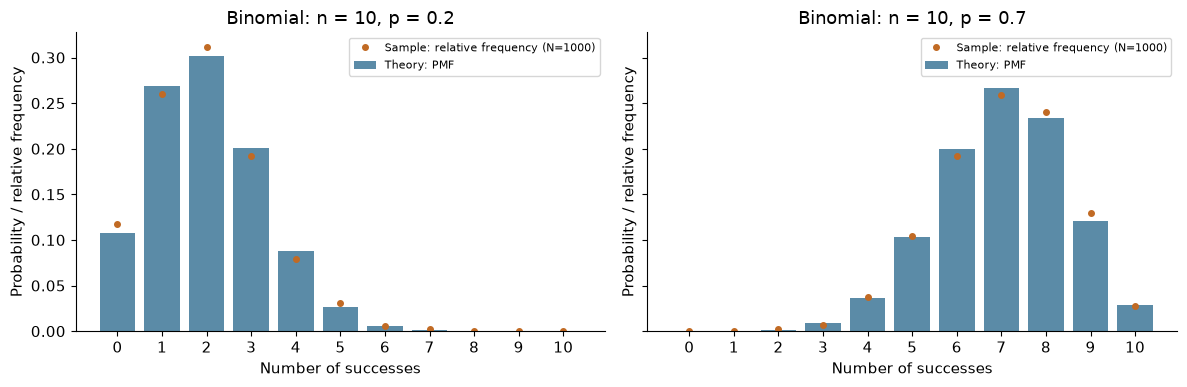

In [6]:
cases = [("Binomial: n = 10, p = 0.2", binom(n=10, p=0.2)), ("Binomial: n = 10, p = 0.7", binom(n=10, p=0.7))]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
left = min(int(model.ppf(0.001)) for _, model in cases)
right = max(int(model.ppf(0.999)) for _, model in cases)
k = np.arange(left, right + 1)

for ax, (label, model) in zip(axes, cases):
    probabilities = model.pmf(k)  # theoretical proaility for each k
    data = model.rvs(size=N, random_state=rng)  # random sample
    relative_frequency = np.array([np.mean(data == value) for value in k])

    ax.bar(k, probabilities, color=THEORY, alpha=0.75, label="Theory: PMF")
    ax.plot(k, relative_frequency, "o", color=SAMPLE, markersize=4,
            label=f"Sample: relative frequency (N={N})")
    ax.set_title(label)
    ax.set_xlabel('Number of successes')
    ax.set_ylabel("Probability / relative frequency")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    if len(k) <= 16:
        ax.set_xticks(k)
    ax.legend(fontsize=8)
    print(label)
    print("First 10 observations:", data[:10])
    print(f"Theory: mean={model.mean():.3f}, variance={model.var():.3f}, SD={model.std():.3f}")
    print(f"Sample: mean={data.mean():.3f}, median={np.median(data):.3f}, variance={data.var(ddof=1):.3f}, SD={data.std(ddof=1):.3f}")

plt.tight_layout()
plt.show()

In [7]:
print("P(X = 2) =", binom.pmf(2, n=10, p=0.2))
print("P(X <= 2) =", binom.cdf(2, n=10, p=0.2))

P(X = 2) = 0.30198988800000004
P(X <= 2) = 0.6777995263999999


Poisson

Poisson: lambda = 1
First 10 observations: [1 1 1 1 0 1 0 1 1 0]
Theory: mean=1.000, variance=1.000, SD=1.000
Sample: mean=0.945, median=1.000, variance=0.881, SD=0.939
Poisson: lambda = 5
First 10 observations: [3 4 5 1 5 4 6 6 7 7]
Theory: mean=5.000, variance=5.000, SD=2.236
Sample: mean=4.999, median=5.000, variance=5.252, SD=2.292


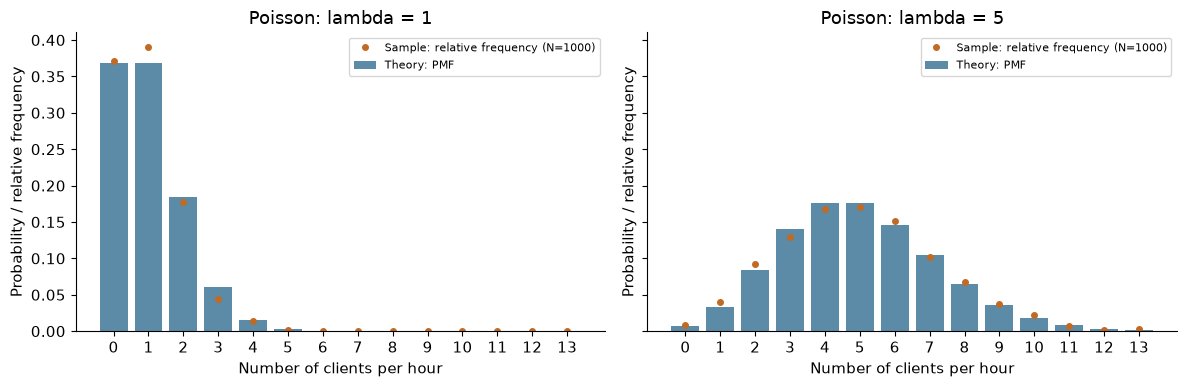

In [8]:
cases = [("Poisson: lambda = 1", poisson(mu=1)), ("Poisson: lambda = 5", poisson(mu=5))]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
left = min(int(model.ppf(0.001)) for _, model in cases)
right = max(int(model.ppf(0.999)) for _, model in cases)
k = np.arange(left, right + 1)

for ax, (label, model) in zip(axes, cases):
    probabilities = model.pmf(k)  # theoretical proaility for each k
    data = model.rvs(size=N, random_state=rng)  # random sample
    relative_frequency = np.array([np.mean(data == value) for value in k])

    ax.bar(k, probabilities, color=THEORY, alpha=0.75, label="Theory: PMF")
    ax.plot(k, relative_frequency, "o", color=SAMPLE, markersize=4,
            label=f"Sample: relative frequency (N={N})")
    ax.set_title(label)
    ax.set_xlabel('Number of clients per hour')
    ax.set_ylabel("Probability / relative frequency")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    if len(k) <= 16:
        ax.set_xticks(k)
    ax.legend(fontsize=8)
    print(label)
    print("First 10 observations:", data[:10])
    print(f"Theory: mean={model.mean():.3f}, variance={model.var():.3f}, SD={model.std():.3f}")
    print(f"Sample: mean={data.mean():.3f}, median={np.median(data):.3f}, variance={data.var(ddof=1):.3f}, SD={data.std(ddof=1):.3f}")

plt.tight_layout()
plt.show()

In [9]:
print("P(X = 3), lambda = 5:", poisson.pmf(3, mu=5))
print("P(X >= 3), lambda = 5:", poisson.sf(2, mu=5))

P(X = 3), lambda = 5: 0.1403738958142805
P(X >= 3), lambda = 5: 0.8753479805169189


Geometric

Geometric: p = 0.35
First 10 observations: [ 1  3  1  2  2  2  5  2  1 12]
Theory: mean=2.857, variance=5.306, SD=2.304
Sample: mean=2.757, median=2.000, variance=5.231, SD=2.287
Geometric: p = 0.7
First 10 observations: [1 1 1 1 1 2 1 1 1 1]
Theory: mean=1.429, variance=0.612, SD=0.782
Sample: mean=1.408, median=1.000, variance=0.650, SD=0.806


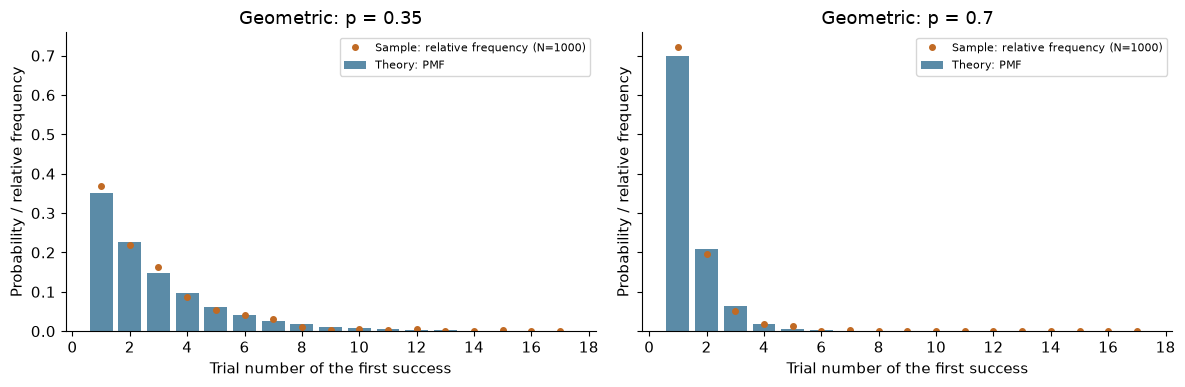

In [10]:
cases = [("Geometric: p = 0.35", geom(p=0.35)), ("Geometric: p = 0.7", geom(p=0.7))]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
left = min(int(model.ppf(0.001)) for _, model in cases)
right = max(int(model.ppf(0.999)) for _, model in cases)
k = np.arange(left, right + 1)

for ax, (label, model) in zip(axes, cases):
    probabilities = model.pmf(k)  # theoretical proaility for each k
    data = model.rvs(size=N, random_state=rng)
    relative_frequency = np.array([np.mean(data == value) for value in k])

    ax.bar(k, probabilities, color=THEORY, alpha=0.75, label="Theory: PMF")
    ax.plot(k, relative_frequency, "o", color=SAMPLE, markersize=4,
            label=f"Sample: relative frequency (N={N})")
    ax.set_title(label)
    ax.set_xlabel('Trial number of the first success')
    ax.set_ylabel("Probability / relative frequency")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    if len(k) <= 16:
        ax.set_xticks(k)
    ax.legend(fontsize=8)
    print(label)
    print("First 10 observations:", data[:10])
    print(f"Theory: mean={model.mean():.3f}, variance={model.var():.3f}, SD={model.std():.3f}")
    print(f"Sample: mean={data.mean():.3f}, median={np.median(data):.3f}, variance={data.var(ddof=1):.3f}, SD={data.std(ddof=1):.3f}")

plt.tight_layout()
plt.show()

In [11]:
print("P(first success on trial 3) =", geom.pmf(3, p=0.35))

P(first success on trial 3) = 0.147875


Negative binomial

Negative binomial: r = 4, p = 0.8
First 10 observations: [5 9 5 5 4 6 4 7 6 4]
Theory: mean=5.000, variance=1.250, SD=1.118
Sample: mean=5.035, median=5.000, variance=1.183, SD=1.088
Negative binomial: r = 4, p = 0.5
First 10 observations: [ 8  7  9  6  6  4  8 14 10 11]
Theory: mean=8.000, variance=8.000, SD=2.828
Sample: mean=8.054, median=7.500, variance=8.079, SD=2.842


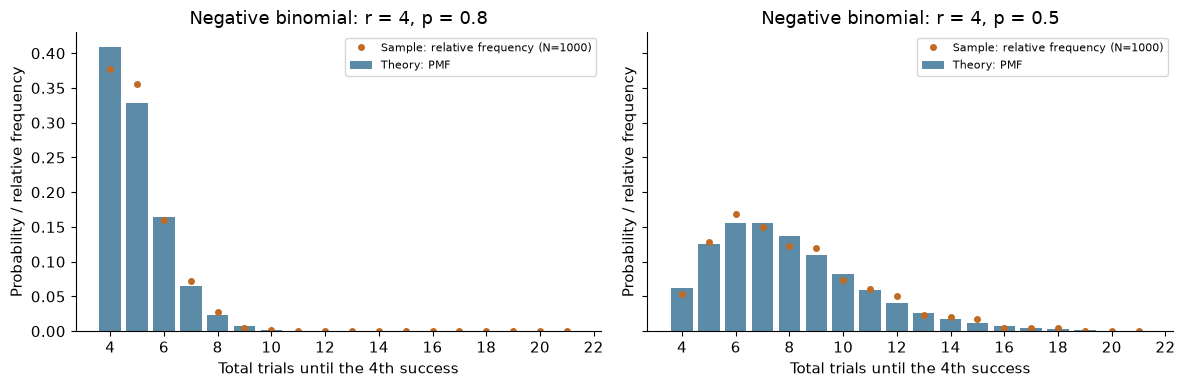

In [12]:
cases = [("Negative binomial: r = 4, p = 0.8", nbinom(n=4, p=0.8, loc=4)), ("Negative binomial: r = 4, p = 0.5", nbinom(n=4, p=0.5, loc=4))]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
left = min(int(model.ppf(0.001)) for _, model in cases)
right = max(int(model.ppf(0.999)) for _, model in cases)
k = np.arange(left, right + 1)

for ax, (label, model) in zip(axes, cases):
    probabilities = model.pmf(k)  # theoretical proaility for each k
    data = model.rvs(size=N, random_state=rng)
    relative_frequency = np.array([np.mean(data == value) for value in k])

    ax.bar(k, probabilities, color=THEORY, alpha=0.75, label="Theory: PMF")
    ax.plot(k, relative_frequency, "o", color=SAMPLE, markersize=4,
            label=f"Sample: relative frequency (N={N})")
    ax.set_title(label)
    ax.set_xlabel('Total trials until the 4th success')
    ax.set_ylabel("Probability / relative frequency")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    if len(k) <= 16:
        ax.set_xticks(k)
    ax.legend(fontsize=8)
    print(label)
    print("First 10 observations:", data[:10])
    print(f"Theory: mean={model.mean():.3f}, variance={model.var():.3f}, SD={model.std():.3f}")
    print(f"Sample: mean={data.mean():.3f}, median={np.median(data):.3f}, variance={data.var(ddof=1):.3f}, SD={data.std(ddof=1):.3f}")

plt.tight_layout()
plt.show()

In [13]:
r, p, k = 4, 0.8, 6
# 4th success on the 6th trial: 2 failuares until 4th success.
probability = nbinom.pmf(k - r, n=r, p=p)
print("P(T = 6) =", probability)  # 0.16384
failures = rng.negative_binomial(n=r, p=p, size=10)
print("Failures:", failures)
print("Total trials:", failures + r)

P(T = 6) = 0.16383999999999996
Failures: [0 1 2 0 2 1 0 0 3 0]
Total trials: [4 5 6 4 6 5 4 4 7 4]


Normal

Normal: mean = 10, SD = 2
Theory: mean=10.000, variance=4.000, SD=2.000
Sample: mean=10.025, median=10.134, variance=3.992, SD=1.998
Normal: mean = 10, SD = 4
Theory: mean=10.000, variance=16.000, SD=4.000
Sample: mean=10.311, median=10.316, variance=16.109, SD=4.014


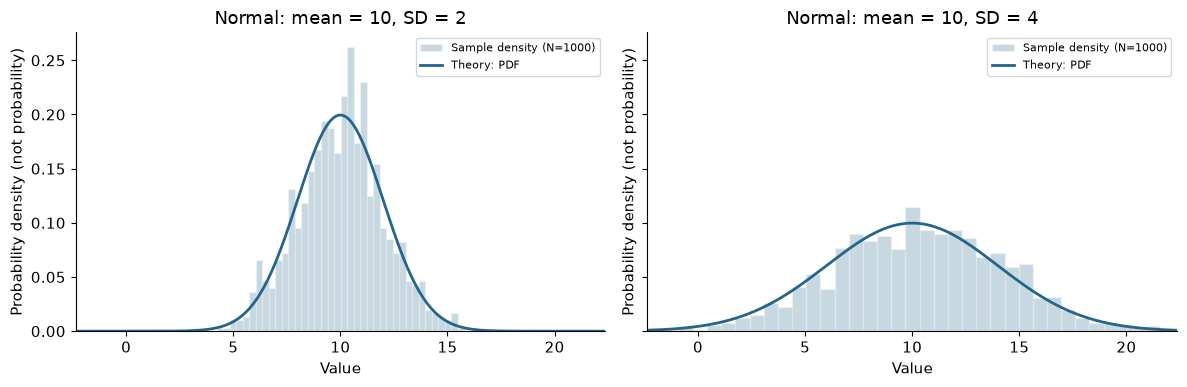

In [14]:
cases = [("Normal: mean = 10, SD = 2", norm(loc=10, scale=2)), ("Normal: mean = 10, SD = 4", norm(loc=10, scale=4))]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
left = min(model.ppf(0.001) for _, model in cases)
right = max(model.ppf(0.999) for _, model in cases)
x = np.linspace(left, right, 1000)

for ax, (label, model) in zip(axes, cases):
    data = model.rvs(size=N, random_state=rng)
    ax.hist(data, bins=40, density=True, color=THEORY, alpha=0.25,
            edgecolor="white", label=f"Sample density (N={N})")
    ax.plot(x, model.pdf(x), color=THEORY, linewidth=2, label="Theory: PDF")
    ax.set_xlim(left, right)
    ax.set_title(label)
    ax.set_xlabel('Value')
    ax.set_ylabel("Probability density (not probability)")
    ax.legend(fontsize=8)
    print(label)
    print(f"Theory: mean={model.mean():.3f}, variance={model.var():.3f}, SD={model.std():.3f}")
    print(f"Sample: mean={data.mean():.3f}, median={np.median(data):.3f}, variance={data.var(ddof=1):.3f}, SD={data.std(ddof=1):.3f}")

plt.tight_layout()
plt.show()

In [15]:
model = norm(loc=10, scale=2)
print("P(8 <= X <= 12) =", model.cdf(12) - model.cdf(8))

P(8 <= X <= 12) = 0.6826894921370859


Z-score

The mean exam score is 1500, the standard deviation is 300, and the student’s score is 1800. Therefore, Z = 1. Assuming a normal distribution, approximately 84.13% of scores are below the student’s score.

Z-score: 1.0
P(X <= 1800) = P(Z <= 1) = 0.8413447460685429
P(X > 1800) = 0.15865525393145707


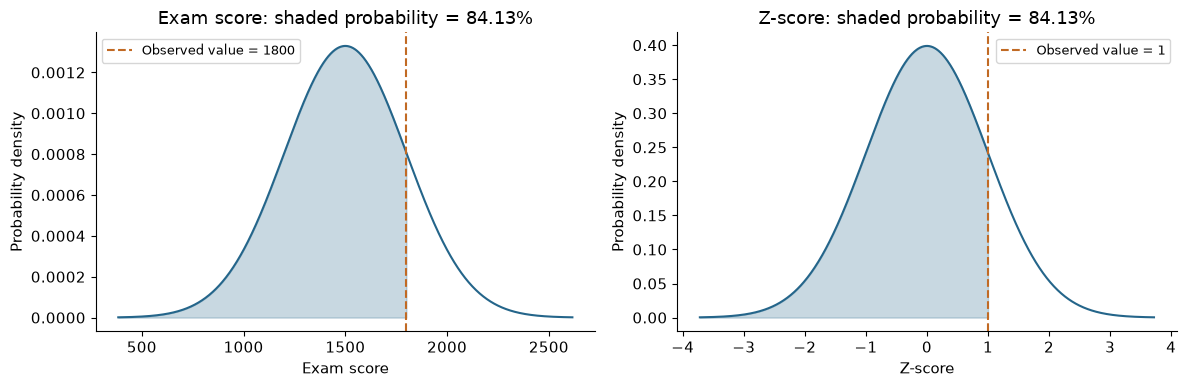

Standardized sample: mean = 0.0
Standardized sample: SD = 0.9999999999999999


In [16]:
mu, sigma, score = 1500, 300, 1800
z_score = (score - mu) / sigma
print("Z-score:", z_score)
print("P(X <= 1800) = P(Z <= 1) =", norm.cdf(z_score))
print("P(X > 1800) =", norm.sf(z_score))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, model, value, label in zip(axes, [norm(mu, sigma), norm()],
                                 [score, z_score], ["Exam score", "Z-score"]):
    x = np.linspace(model.ppf(0.0001), model.ppf(0.9999), 1000)
    ax.plot(x, model.pdf(x), color=THEORY)
    shaded_x = np.linspace(x[0], value, 500)
    ax.fill_between(shaded_x, model.pdf(shaded_x), color=THEORY, alpha=0.25)
    ax.axvline(value, color=SAMPLE, linestyle="--", label=f"Observed value = {value:g}")
    ax.set_title(f"{label}: shaded probability = {norm.cdf(z_score):.2%}")
    ax.set_xlabel(label)
    ax.set_ylabel("Probability density")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

scores = rng.normal(loc=mu, scale=sigma, size=N)
z_sample = (scores - scores.mean()) / scores.std(ddof=1)
print("Standardized sample: mean =", round(z_sample.mean(), 10))
print("Standardized sample: SD =", z_sample.std(ddof=1))

# Task 1.
College smokers. At a university, 13% of students smoke.
Calculate the expected number of smokers in a random sample of 100 students from this university.

In [17]:
#Problem is binomial as there are n independent trials with fixed p success rate. Then E[X] = np
n = 100
p = 0.13
ex = n*p
print(ex)

13.0


# Task 2.
Ace of clubs wins. Consider the following card game with a well-shuﬄed deck of cards. If you draw a
red card, you win nothing. If you get a spade, you win 5 dollars. For any club, you win 10 dollars plus an extra 20 dollars for the
ace of clubs.

a) Create a probability model for the amount you win at this game. Also, find the expected winnings for a
single game and the standard deviation of the winnings.



In [36]:
res = ['Red card', 'Spade', 'Club, not ace', 'Ace of clubs']

#Assume its french deck with 52 cards, 13 for each suits, 9 numerics + J, Q, K, A
p = [0.5, 0.25, 12/52, 1/52]
win = [0, 5, 10, 30]

df = pd.DataFrame({'res' : res, 'X' : win, 'P(X)' : p})

#Following definition of E[X] for discrete variable X, E[X] = p1*X1 + .... + pnXn

Ex = float(np.sum(df['X'] * df['P(X)']))
print('E[X]: ', Ex)


#Will calculate std as sqrt(variance), where variance = E[X^2] - E^2[X] 

df['X2'] = np.array(df['X']) ** 2

display(df)

Ex2 = float(np.sum(df['X2'] * df['P(X)']))
D = Ex2 - Ex**2

std = np.sqrt(D)
print('Std:', std)

E[X]:  4.134615384615385


,res,X,P(X),X2
0,Red card,0,0.500000,0
1,Spade,5,0.250000,25
2,"Club, not ace",10,0.230769,100
3,Ace of clubs,30,0.019231,900


Std: 5.435031831177914


b) What is the maximum amount you would be willing to pay to play this game? Explain your reasoning.

I am willing to pay E[X] at max, to make profit on average. Not more because house always wins long-term

# Task 3. 
Baggage fees. An airline charges the following baggage fees: 25 dollars for the first bag and 35 dollars for the
second. Suppose 54% of passengers have no checked luggage, 34% have one piece of checked luggage and
12% have two pieces. We suppose a negligible portion of people check more than two bags.
(a) Build a probability model, compute the average revenue per passenger, and compute the corresponding
standard deviation.
(b) About how much revenue should the airline expect for a flight of 120 passengers? With what standard
deviation? Note any assumptions you make and if you think they are justified.

In [48]:
case = ['no bags', '1 bag' , '2 bags']
X = [0, 25, 60]
p = [0.54, 0.34, 0.12]

df = pd.DataFrame({'case':case, 'X': X , 'P(X)' : p})

#This is discrete distribution as P(Xi) != 0
#Average revenue per passenger = E[X] = p1*X1 + .... + pnXn
#Std = sqrt(variance), where variance = E[X^2] - E^2[X] 

Ex = np.sum(df['X'] * df['P(X)'])
df['X2'] = df['X'] ** 2

display(df)
#Assume that probabilities from problem statement also hold for random flight of 120 passangers
# Also assume that passenger decide to pick n of bags randomly and independently
# Both assumptions are justified to simplify model and generalize calculations
Ex2 = np.sum(df['X2'] * df['P(X)'])
var = Ex2 - Ex**2
std = np.sqrt(var)

print('Average revenue per passenger: ', Ex)
print('Standart deviation :', std)
print(f'For a flight with 120 passenger, airline should expect revenue of {120 * Ex}, with std {std * np.sqrt(120)}')

,case,X,P(X),X2
0,no bags,0,0.54,0
1,1 bag,25,0.34,625
2,2 bags,60,0.12,3600


Average revenue per passenger:  15.7
Standart deviation : 19.950187969039288
For a flight with 120 passenger, airline should expect revenue of 1884.0, with std 218.5433595422199


# Task 4.

Hepatitis C.
Hepatitis C is spread primarily through contact with the blood of an infected person,
and is nearly always transmitted through needle sharing among intravenous drug users. Suppose that in a
month’s time, an IV drug user has a 30% chance of contracting hepatitis C through needle sharing. What is
the probability that 3 out of 5 IV drug users contract hepatitis C in a month? Assume that the drug users live
in diﬀerent parts of the country.

In [60]:
#the problem is binomial as it have fixed number of independent trials k (users live in different parts of the country) and contant success rate p
#Then the probability asked for, can be calculated as Pn(k) = (n choose k) * p^k * q^(n-k)
def n_choose_k(n,k):

    nck  = math.factorial(n) / (math.factorial(k) * math.factorial(n-k))
    return(nck)
    

p = 0.3
k = 3
n = 5
probability = n_choose_k(n,k) * p**k * (1-p)**(n-k)
print('Probabiliy that 3 out of 5 IV drug users contract hepatitis C in a month: ', probability)



#sanity check if sum of P == 1
cumsum = 0
for k in range(0, n+1):
    cumsum +=   n_choose_k(n,k) * p**k * (1-p)**(n-k)
print(cumsum)

Probabiliy that 3 out of 5 IV drug users contract hepatitis C in a month:  0.13229999999999997
0.9999999999999999


# Task 5.
Hyponatremia. Hyponatremia (low sodium levels) occurs in a certain proportion of marathon runners
during a race. Suppose that historically, the proportion of runners who develop hyponatremia is 0.12. In a
certain marathon, there are 200 runners participating.
(a) How many cases of hyponatremia are expected during the marathon?
(b) What is the probability of more than 30 cases of hyponatremia occurring?

In [63]:
# This problem is binomial as there are n number of trials and constant success rate p.
n = 200
p = 0.12
# For a) expected number of hyponatremia cases = E[X] = n * p for binomial distribution

Ex = n * p 
print('Expected number of hyponatremia cases:', Ex)

#For b P(X>30) = 1 - P(X<=30). Because tests are independent, P(x<=30) = P(0) + P(1) ... + P(30)

P_less_or_equal_30 = 0

for k in range(0, 31):
    P_less_or_equal_30 += n_choose_k(n,k) * p**k * (1-p)**(n-k)

P_more_than_30 = 1 - P_less_or_equal_30

print('probability of more than 30 cases of hyponatremia occurring:', P_more_than_30)

Expected number of hyponatremia cases: 24.0
probability of more than 30 cases of hyponatremia occurring: 0.0820938888257271


# Task 6
The standard normal distribution. 
Consider the standard normal distribution with mean µ= 0 and
standard deviation σ= 1.
(a) (b) (c) (d) (e) What is the probability that an outcome Zis greater than 2.60?
What is the probability that Zis less than 1.35?
What is the probability that Zis between -1.70 and 3.10?
What value of Zcuts oﬀ the upper 15% of the distribution?
What value of Zmarks oﬀ the lower 20% of the distribution?

In [78]:
mu = 0
sigma = 1

#x = np.linspace(model.ppf(0.0001), model.ppf(0.9999), 1000)   
#plt.plot(x, model.pdf(x))
#plt.tight_layout()
#plt.show()

#a)
p1 = 1 - norm.cdf(2.6)
print(f'a) probability that an outcome Z is greater than 2.60? is {p1}')

#b) 
p2 = norm.cdf(1.35)
print(f'b) the probability that Z is less than 1.35 is {p2}')

#c)
p3 = norm.cdf(3.10) - norm.cdf(-1.7)
print(f'c) probability that Zis between -1.70 and 3.10 is {p3} ')


#d) 0.85 = norm.cdf(Z). From z values table (https://numiqo.com/tutorial/z-distribution): -1.04 cuts bottom 15%, then from normal distribution symmetry, z = 1.04 cuts top 15%
print(f'd) Z score 1.04 cuts off approx upper 15% of distribtuion, or bottom {norm.cdf(1.04)*100}% ')


#e) The same approach as d)
print(f'e) Z score of -0.84 cuts off bottom 20% of distribtuion, ({norm.cdf(-0.84)*100}%)')

a) probability that an outcome Z is greater than 2.60? is 0.004661188023718732
b) the probability that Z is less than 1.35 is 0.911492008562598
c) probability that Zis between -1.70 and 3.10 is 0.9544669340282387 
d) Z score 1.04 cuts off approx upper 15% of distribtuion, or bottom 85.08300496690187% 
e) Z score of -0.84 cuts off bottom 20% of distribtuion, (20.045419326044968%)


# Task 7
GRE scores. The Graduate Record Examination (GRE) is a standardized test commonly taken by grad-
uate school applicants in the United States. The total score is comprised of three components: Quantitative
Reasoning, Verbal Reasoning, and Analytical Writing. The first two components are scored from 130 - 170.
The mean score for Verbal Reasoning section for all test takers was 151 with a standard deviation of 7, and
the mean score for the Quantitative Reasoning was 153 with a standard deviation of 7.67. Suppose that both
distributions are nearly normal.
(a) A student scores 160 on the Verbal Reasoning section and 157 on the Quantitative Reasoning section.
Relative to the scores of other students, which section did the student perform better on?
(b) Calculate the student’s percentile scores for the two sections. What percent of test takers performed better
on the Verbal Reasoning section?
(c) Compute the score of a student who scored in the 80th percentile on the Quantitative Reasoning section.
(d) Compute the score of a student who scored worse than 70% of the test takers on the Verbal Reasoning
section.

In [103]:
# Q = [130-170], mu = 153, std = 7,67
# V = [130-170], mu = 151, std = 7


Q_mu = 153
Q_std = 7.67
Q_min = 130
Q_max = 170


V_mu = 151
V_std = 7
V_min = 130
V_max = 170


Q_dist = stats.norm(loc=Q_mu, scale=Q_std)
V_dist = stats.norm(loc=V_mu, scale=V_std)


#a,b)
V_x = 160
Q_x = 157


V_percentile = V_dist.cdf(V_x)
Q_percentile = Q_dist.cdf(Q_x)
V_better_performers = round(1 - V_percentile,3)

print(f'a,b) Student performed on verbal better (percentile is {round(V_percentile*100,3)} vs {round(Q_percentile*100,3)} for quant). {V_better_performers} of students performed better on verbal reasoning')


#c) 

score_c = np.round(Q_dist.ppf(0.8),3)

print(f'c) Score of student with percentile 80 on quantitative reasoning is {score_c}')


#d)

score_d = np.round(V_dist.ppf(0.3),3)
print(f'd) Score of student who performed worse than 70% of scorers (i.e in bottom 30%) on verbal reasoning is {score_d}')


a,b) Student performed on verbal better (percentile is 90.073 vs 69.9 for quant). 0.099 of students performed better on verbal reasoning
c) Score of student with percentile 80 on quantitative reasoning is 159.455
d) Score of student who performed worse than 70% of scorers (i.e in bottom 30%) on verbal reasoning is 147.329


# Task 8

Computing Poisson probabilities. This is a simple exercise in computing probabilities for a Poisson
random variable. Suppose that Xis a Poisson random variable with rate parameter λ= 2. Calculate P(X= 2),
P(X≤2), and P(X≥3).

In [116]:
poisson_dist = poisson(mu = 2)

print('for Poisson distribtuion with lambda = 2')
#a)
p1 = round(poisson_dist.pmf(k = 2),3)
print(f'P(X= 2) is {p1}')

#b)
p2 = round(poisson_dist.cdf(x = 2),3)
print(f'P(X<= 2) is {p2}')

#c)
p3 = round(1 - poisson_dist.cdf(x = 2),3)
print(f'P(X≥3) is {p3}')

for Poisson distribtuion with lambda = 2
P(X= 2) is 0.271
P(X<= 2) is 0.677
P(X≥3) is 0.323


# Task 9

Customers at a coffee shop. A coﬀee shop serves an average of 75 customers per hour during the
morning rush.
(a) What are the mean and the standard deviation of the number of customers this coﬀee shop serves in one
hour during this time of day?
(b) Would it be considered unusually low if only 60 customers showed up to this coﬀee shop in one hour
during this time of day?
(c) Calculate the probability that this coﬀee shop serves 70 customers in one hour during this time of day.

In [131]:
# This is Poisson problem as data since variable X describes n of event happening over some interval
# So number mean = E[X] = std(X)**2 = lambda = 75

lambd = 75

#a)

print(f'a) Mean n of customers per hour is {lambd}, std is {round(np.sqrt(lambd),3)}')


#b)

dist = poisson(mu = 75)
p1 = float(np.round(dist.pmf(k = 60),5))
p1_2 = float(np.round(dist.cdf(x = 60),3))
lower_threshold = lambd - 2*np.sqrt(lambd)

print(f'b) assume that values less than mu-2sigma = {lower_threshold} are unusual. Since 60 is more than this threshold, its not highly unusual')
print(f'On the other hand, P(X = 60) is {p1}. This is likely low')
print(f'Also P(X<= 60) is {p1_2}. Still below 5% threshold, so likely low')


#c)

p2 = float(np.round(dist.pmf(k = 70),5))
print(f'c) P(X = 70) is {p2}')


a) Mean n of customers per hour is 75, std is 8.66
b) assume that values less than mu-2sigma = 57.67949192431122 are unusual. Since 60 is more than this threshold, its not highly unusual
On the other hand, P(X = 60) is 0.01027. This is likely low
Also P(X<= 60) is 0.043. Still below 5% threshold, so likely low
c) P(X = 70) is 0.04016


# Task 10
Hemophilia. Hemophilia is a sex-linked bleeding disorder that slows the blood clotting process. In
severe cases of hemophilia, continued bleeding occurs after minor trauma or even in the absence of injury.
Hemophilia aﬀects 1 in 5,000 male births. In the United States, about 400 males are born with hemophilia
each year; there are approximately 4,000,000 births per year. Note: this problem is best done using statistical
software.
(a) What is the probability that at most 380 newborns in a year are born with hemophilia?
(b) What is the probability that 450 or more newborns in a year are born with hemophilia?
(c) Consider a hypothetical country in which there are approximately 1.5 million births per year. If the inci-
dence rate of hemophilia is equal to that in the US, how many newborns are expected to have hemophilia
in a year, with what standard deviation?

In [150]:
#This is binomial problem as there is fixed number of trials with constant success rate. However since both n and k are big were likely have to use poisson approximation
# Assume that P(birth of male) = P(birth of female). Also for simplicity assume that only males have hemophilia.

haemophilia_dist = poisson(mu = 400)

p = 1/5000
n = 4000000
n /= 2

#a)
p1 = binom.cdf(n = n, k = 380, p = p)
p1_poiss = haemophilia_dist.cdf(380)
print(f'a) Probability of at most 380 newborn with haemophilia is')
print(f'From binomial distribution {p1}')
print(f'From poisson approximation {p1_poiss}')

#So my pc calculates binom for large numbers quite fast so will stick to binom distribution as its more correct

#b)

p2 = 1 - binom.cdf(n = n, k = 450, p = p) + binom.pmf(n =n, k = 450, p = p)

print(f'b) probability that 450 or more newborns in a year are born with hemophilia is {p2}')


#c)

#For binomial distribtuion, mean = E[X] = np, std = sqrt(D(X)) = sqrt(npq)
n = 1500000 / 2
Ex = n*p
std = np.sqrt(n*p*(1-p))

print(f'For that country, mean number of haemophilic newborns is {Ex} with std of {std}')


a) Probability of at most 380 newborn with haemophilia is
From binomial distribution 0.16483437395419406
From poisson approximation 0.16485898532237425
b) probability that 450 or more newborns in a year are born with hemophilia is 0.0074491799725018
For that country, mean number of haemophilic newborns is 150.0 with std of 12.24622390780113


# Task 11

On 70% of days, a hospital admits at least one heart attack patient. On 30% of the days, no heart attack patients are admitted. Identify each case below as a binomial or negative binomial case, and compute the probability. (a) What is the probability the hospital will admit a heart attack patient on exactly three days this week? (b) What is the probability the second day with a heart attack patient will be the fourth day of the week? (c) What is the probability the fifth day of next month will be the first day with a heart attack patient?²⁸

In [163]:
#a) is binomial - 7 trials, fixed success rate 
p = 0.7
k = 3
n = 7
p_1 = round(n_choose_k(n,k) * p**k * (1-p)**(n-k),3)

print(f'a) probability the hospital will admit a heart attack patient on exactly three days this week is {p_1}')


#b) is negative binomial as we finding probability that r-th success happens on k-th trial


k = 4
r = 2
p_2 = round(n_choose_k(k-1, r-1) * p**r * (1-p)**(k-r),3)

print(f'b) probability the second day with a heart attack patient will be the fourth day of the week is {p_2}')

#c) is negative binomial problem as we finding probability that r-th success happens on k-th trial.
# Assume that 5th day of next month = 5th day of some week 

k = 5
r = 1

p_3 = round(n_choose_k(k-1, r-1) * p**r * (1-p)**(k-r),3)


print(f'c) probability the fifth day of next month will be the first day with a heart attack patient? {p_3}')


a) probability the hospital will admit a heart attack patient on exactly three days this week is 0.097
b) probability the second day with a heart attack patient will be the fourth day of the week is 0.132
c) probability the fifth day of next month will be the first day with a heart attack patient? 0.006
